#Download the dataset from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/customer-churn")

print("Path to dataset files:", path)

100%|██████████| 241k/241k [00:00<00:00, 19.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/willianoliveiragibin/customer-churn/versions/1


# Import Kit

In [2]:
# for data hanling
import pandas as pd
import numpy as np

# for data visualization
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator

In [60]:
# for data preprocessing and splitting
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
# for evaluate model performance
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, RocCurveDisplay, auc

In [4]:
import os
print(f"Files in dataset folder:{os.listdir(path)}")

Files in dataset folder:['Customer Churn new.csv']


In [5]:
file_path = os.path.join(path, "Customer Churn new.csv")
df = pd.read_csv(file_path)

# Exploratory Data Analysis, EDA

## Data Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 859.5+ KB


In [7]:
# check if any column has missing values
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
EstimatedSalary,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# show the unique values
df[['Geography']].drop_duplicates()

,Geography
0,France
3,Germany
7,Spain


In [10]:
# Show min and max age
print("="*10, "Age", "=" *10)
print(f"Min Age: {df['Age'].min()}")
print(f"Max Age: {df['Age'].max()}\n")

# Show basic stats of Credit Score, Balance, Tenure and Estimated Salary
print("="*10, "Credit Score", "=" *10)
print(f"Min:{df['CreditScore'].min()}")
print(f"Max: {df['CreditScore'].max()}")
print(f"Median: {df['CreditScore'].median()}")
print(f"Mean: {df['CreditScore'].mean():.2f}\n")

print("="*10, "Balance", "=" *10)
print(f"Min: {df['Balance'].min()}")
print(f"Max: {df['Balance'].max()}")
print(f"Median: {df['Balance'].median():.2f}")
print(f"Mean: {df['Balance'].mean():.2f}\n")

print("="*10, "Tenure", "=" *10)
print(f"Min: {df['Tenure'].min()}")
print(f"Max: {df['Tenure'].max()}")
print(f"Mean: {df['Tenure'].mean():.2f}\n")

print("="*10, "Estimated Salary", "=" *10)
print(f"Min: {df['EstimatedSalary'].min()}")
print(f"Max: {df['EstimatedSalary'].max()}")
print(f"Median: {df['EstimatedSalary'].median():.2f}")
print(f"Mean: {df['EstimatedSalary'].mean():.2f}")
print(f"25% Quantile: {df['EstimatedSalary'].quantile(0.25):.2f}")
print(f"75% Quantile: {df['EstimatedSalary'].quantile(0.75):.2f}")

========== Age ==========
Min Age: 18
Max Age: 92

========== Credit Score ==========
Min:350
Max: 850
Median: 652.0
Mean: 650.53

========== Balance ==========
Min: 0.0
Max: 250898.09
Median: 97198.54
Mean: 76485.89

========== Tenure ==========
Min: 0
Max: 10
Mean: 5.01

========== Estimated Salary ==========
Min: 11.58
Max: 199992.48
Median: 100193.91
Mean: 100090.24
25% Quantile: 51002.11
75% Quantile: 149388.25


## Visualization

In [11]:
df_eda = df.copy()

### Overall

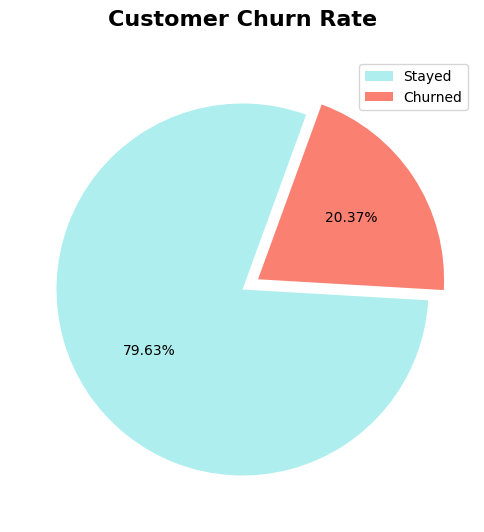

In [12]:
# pie chart, overall churn rate
labels = ['Stayed', 'Churned']
sizes = df_eda['Exited'].value_counts()
plt.figure(figsize=(6,8))
plt.pie(sizes, autopct = '%1.2f%%',startangle = 70, colors = ['paleturquoise','salmon'],explode=(0,0.1))
plt.legend(labels)
plt.title('Customer Churn Rate\n', fontsize=16, weight = 'bold')
plt.show()

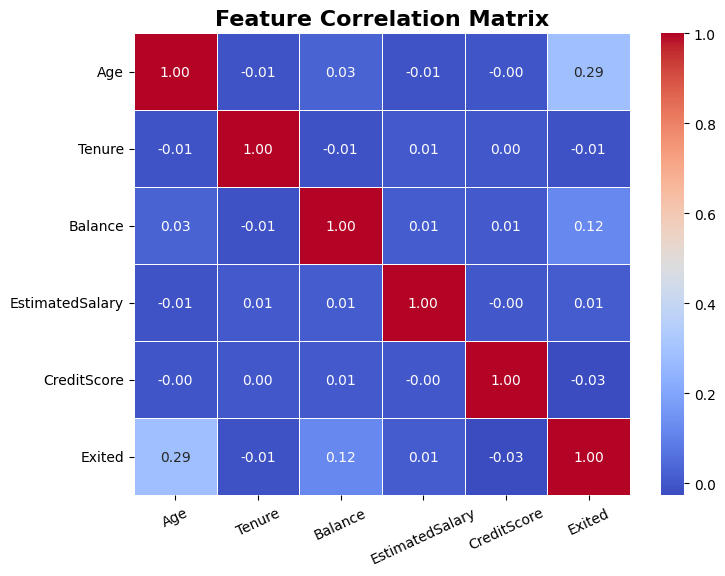

In [13]:
# feature correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df_eda[['Age', 'Tenure', 'Balance', 'EstimatedSalary', 'CreditScore','Exited']].corr(), fmt=".2f", annot=True, cmap='coolwarm',linewidths=0.5)
plt.xticks(rotation=25)
plt.title("Feature Correlation Matrix", fontsize=16, weight = 'bold')
plt.show()

### Geography

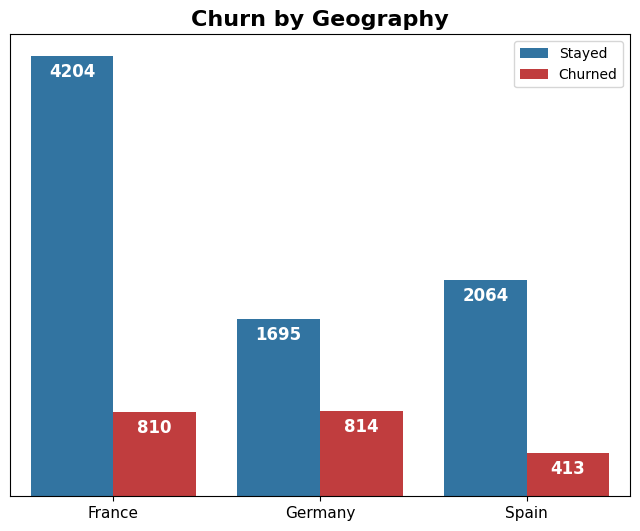

In [14]:
# bar chart, customer churn by geography
plt.figure(figsize=(8,6))
ax1 = sns.countplot(data=df_eda, x='Geography', hue='Exited', width = 0.8, palette={0: '#1f77b4', 1: '#d62728'},)
for container in ax1.containers:
    ax1.bar_label(container, label_type='edge', padding=-18, color='white', weight='bold', fontsize=12)

ax1.yaxis.set_visible(False)
plt.xlabel('')
plt.xticks(fontsize=11)
plt.legend(labels = ['Stayed','Churned'])
plt.title('Churn by Geography', fontsize=16, weight = 'bold')
plt.show()

### Gender

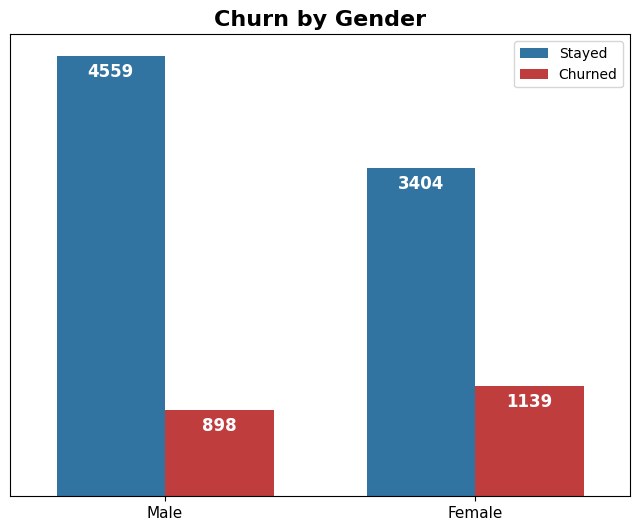

In [15]:
# bar chart, customer churn by gender
plt.figure(figsize=(8,6))
ax2 = sns.countplot(data=df_eda, x='Gender', hue='Exited', width = 0.7, palette={0: '#1f77b4', 1: '#d62728'})
for container in ax2.containers:
    ax2.bar_label(container, label_type='edge', padding=-18, color='white', weight='bold', fontsize=12)

ax2.yaxis.set_visible(False)
plt.xlabel('')
plt.xticks(fontsize=11)
plt.legend(labels = ['Stayed','Churned'])
plt.title('Churn by Gender', fontsize=16, weight = 'bold')
plt.show()

### Age

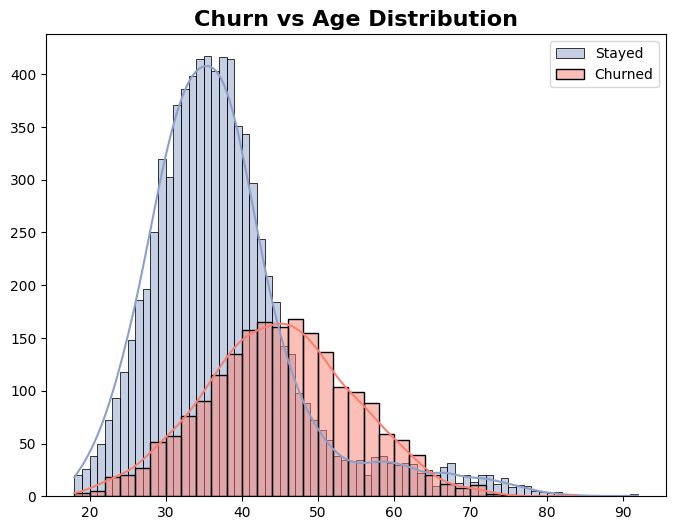

In [16]:
# histogram, compare age distribution between stayed and churned customers
plt.figure(figsize=(8,6))
sns.histplot(df_eda[df_eda['Exited']==0]['Age'], kde=True, color='#8da0cb', label='Stayed')
sns.histplot(df_eda[df_eda['Exited']==1]['Age'], kde=True, color='#fb8071', label='Churned')
plt.legend()
plt.ylabel('')
plt.xlabel('')
plt.title("Churn vs Age Distribution", fontsize=16, weight = 'bold')
plt.show()

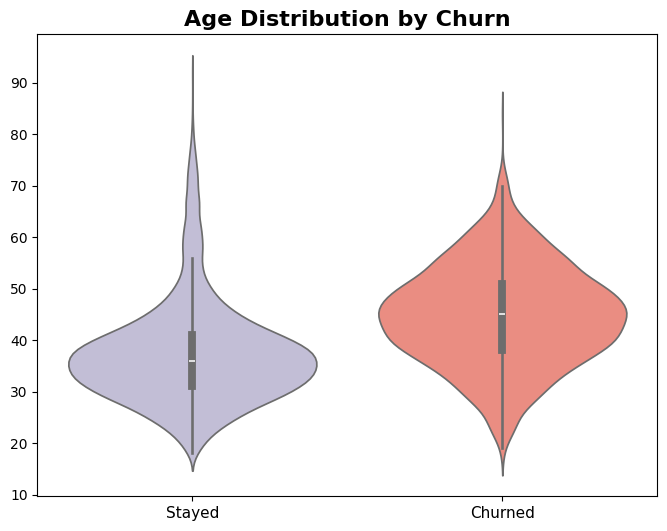

In [17]:
# violin plot, compare age distribution between stayed and churned customers
plt.figure(figsize=(8,6))
sns.violinplot(data=df_eda, x='Exited', y='Age', hue = 'Exited', palette={0: '#bfbada', 1: '#fb8071'}, legend = False)
plt.title('Age Distribution by Churn', fontsize=16, weight = 'bold')
plt.xlabel('')
plt.ylabel('')
plt.xticks([0, 1], ['Stayed', 'Churned'], fontsize=11)
plt.show()

### Tenure

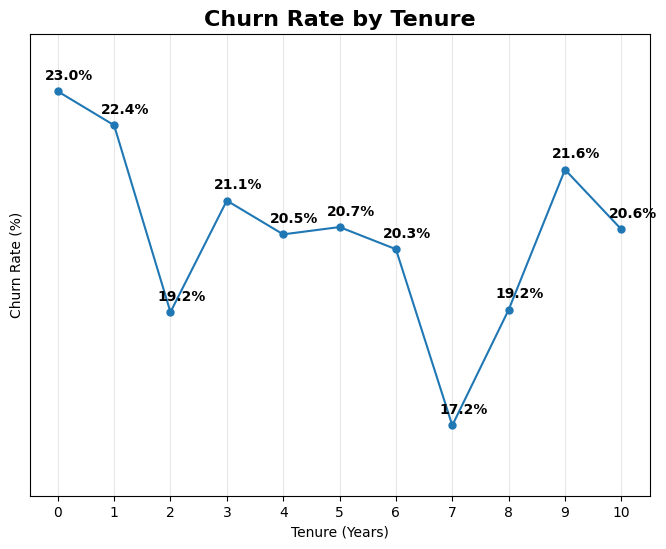

In [18]:
# line chart, churn rate for each tenure
# The number of churned customers divided by the total number of customers in each year
tenure_churn = df_eda.groupby('Tenure')['Exited'].mean() * 100
plt.figure(figsize=(8,6))
tenure_churn.plot(marker = 'o', markersize = 5)

plt.xticks(ticks = range(0,11,1))
plt.ylim(16,24)
plt.yticks([])
for x, y in zip(tenure_churn.index, tenure_churn.values):
    plt.text(x + 0.2, y + 0.4, f'{y:.1f}%', ha='center', va='top', fontsize=10, color='black', weight = 'bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure (Years)')
plt.grid(alpha=0.3)
plt.title('Churn Rate by Tenure', fontsize=16, weight = 'bold')
plt.show()

### Balance

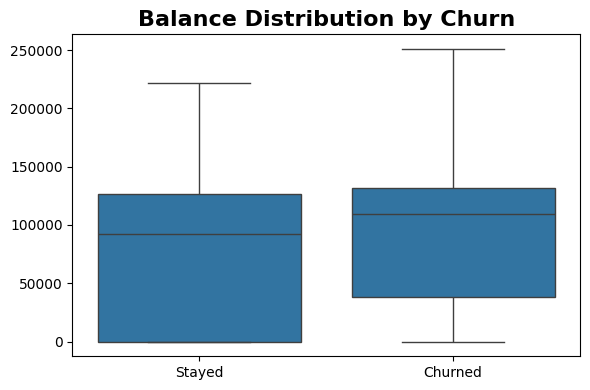

In [19]:
# boxplot, compare the account balance between stayed and churned customers
plt.figure(figsize=(6, 4))
sns.boxplot(x='Exited', y='Balance', data=df_eda)
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('')
plt.ylabel('')
plt.title('Balance Distribution by Churn', fontsize=16, weight = 'bold')
plt.tight_layout()
plt.show()

/tmp/ipython-input-102178544.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_churn1 = df_balance_nonzero.groupby('BalanceBin')['Exited'].mean().reset_index()


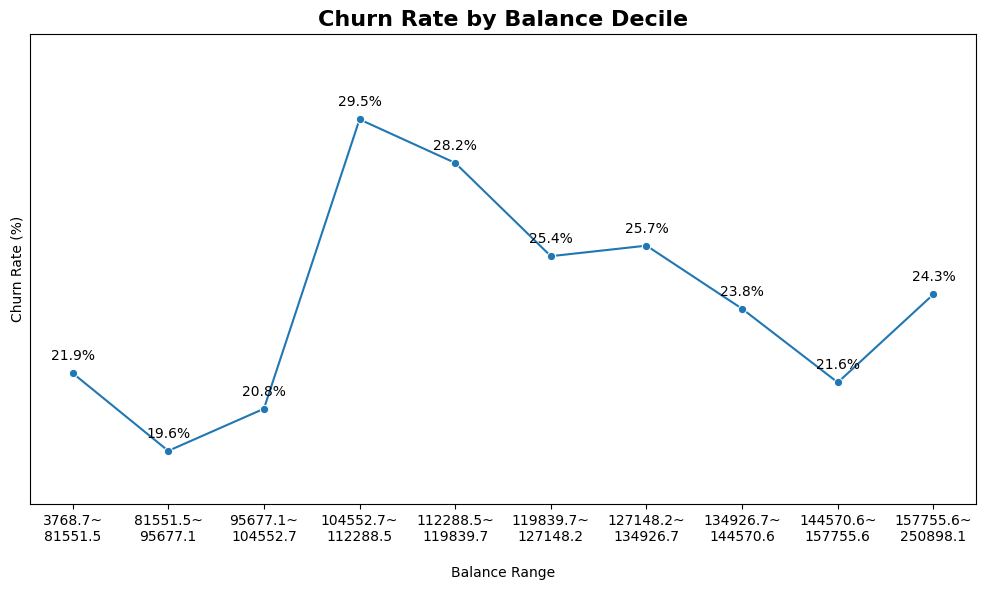

In [20]:
# line chart, analyzes how churn rate changes across different balance ranges

# keep balance greater than 0
df_balance_nonzero = df_eda[df_eda['Balance'] > 0].copy()
# divide balance into 10 equal-sized groups (bins)
df_balance_nonzero['BalanceBin'] = pd.qcut(df_balance_nonzero['Balance'], q=10, duplicates='drop')

# calculate churn rate for each balance group
bin_churn1 = df_balance_nonzero.groupby('BalanceBin')['Exited'].mean().reset_index()
bin_churn1['Exited'] = bin_churn1['Exited'] * 100  # Convert to percentage

# create readable labels for each balance range
def format_interval(interval):
    return f"{interval.left:.1f}~\n{interval.right:.1f}"

bin_churn1['BalanceBinLabel'] = bin_churn1['BalanceBin'].apply(format_interval)

plt.figure(figsize=(10, 6))
sns.lineplot(data=bin_churn1, x='BalanceBinLabel', y='Exited', marker='o')
# add data labels for each point
for x, y in zip(bin_churn1['BalanceBinLabel'], bin_churn1['Exited']):
    plt.text(x, y + 0.3, f"{y:.1f}%", ha='center', va='bottom', fontsize=10)
plt.xlabel('\nBalance Range')
plt.ylabel('Churn Rate (%)')
plt.ylim(18, 32)
plt.yticks([]) # Hide y-axis ticks
# Format y-axis values as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.title('Churn Rate by Balance Decile', fontsize=16, weight = 'bold')
plt.tight_layout()
plt.show()

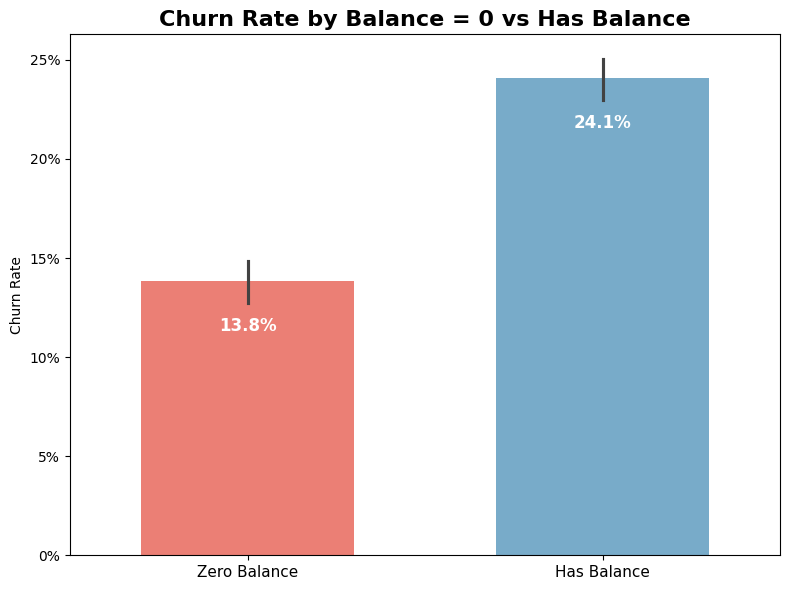

In [21]:
# bar chart with confidence intervals, compares churn rates between zero balance and positive balance

# classify customers by balance = 0 or > 0
df_eda['BalanceType'] = df_eda['Balance'].apply(lambda x: 'Zero Balance' if x == 0 else 'Has Balance')

# set display order and colors for the categories
order = ['Zero Balance', 'Has Balance']
palette = {'Zero Balance': '#FF6F61', 'Has Balance': '#6BAED6'}

plt.figure(figsize=(8, 6))
ax3 = sns.barplot(
    data=df_eda,
    x='BalanceType',
    y='Exited',
    hue='BalanceType',
    order=order,
    palette=palette,
    width=0.6,
    errorbar=('ci', 95),
)

# add percentage labels inside each bar
for p in ax3.patches:
    height = p.get_height()
    ax3.text(p.get_x() + p.get_width() / 2,
            height - 0.025,
            f'{height:.1%}',
            ha='center',
            fontsize=12,
            fontweight='bold',
            color='white')

ax3.set_xticks([0, 1])
ax3.set_xticklabels(order, fontsize=11)
# format y-axis as percentages
ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.xlabel('')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Balance = 0 vs Has Balance', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

### Credit Score

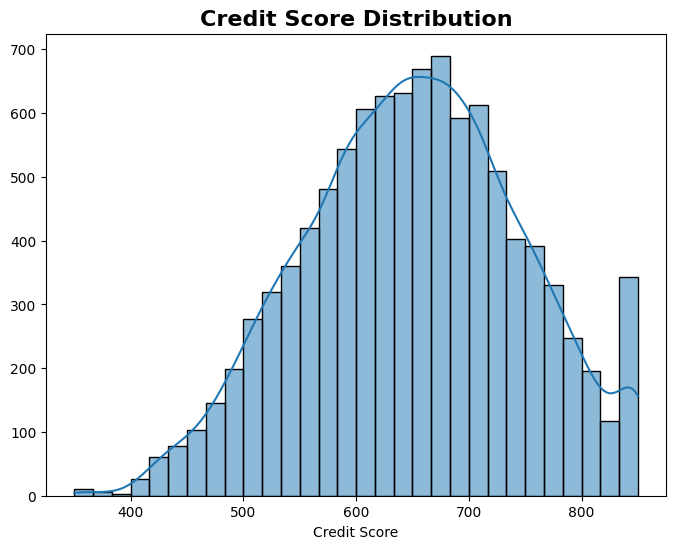

In [22]:
# histogram, credit score distribution
plt.figure(figsize=(8, 6))
sns.histplot(df_eda['CreditScore'], bins=30, kde=True)
plt.xlabel('Credit Score')
plt.ylabel('')
plt.title('Credit Score Distribution', fontsize=16, weight = 'bold')
plt.show()

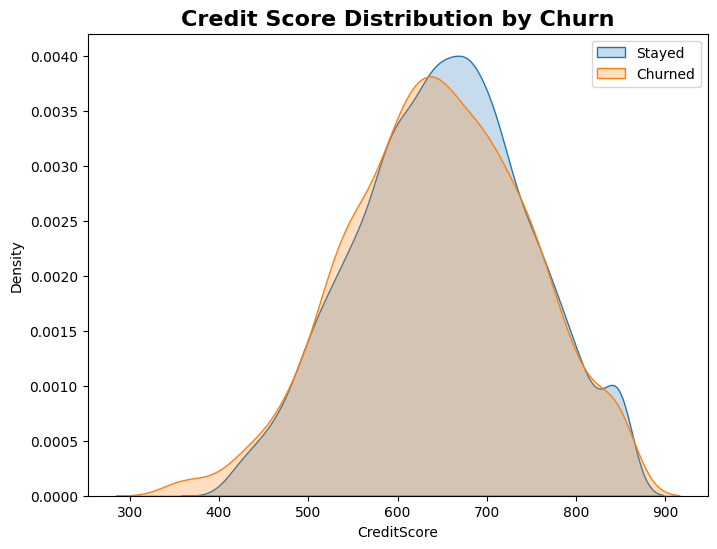

In [23]:
#  KDE plot(smoothed curve chart), the distribution of credit scores between stayed and churned customers
plt.figure(figsize=(8,6))
sns.kdeplot(df_eda[df_eda['Exited'] == 0]['CreditScore'], label='Stayed', fill=True)
sns.kdeplot(df_eda[df_eda['Exited'] == 1]['CreditScore'], label='Churned', fill=True)
plt.legend()
plt.title('Credit Score Distribution by Churn', fontsize=16, weight = 'bold')
plt.show()

### Estimated Salary

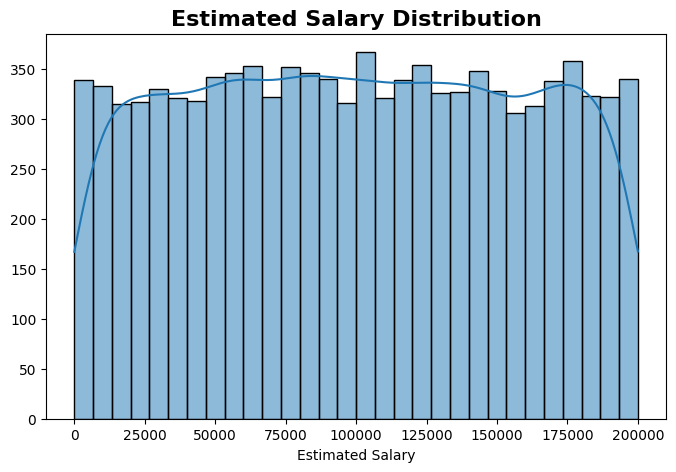

In [24]:
# histogram, estimated salary distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_eda['EstimatedSalary'], bins=30, kde=True)
plt.xlabel('Estimated Salary')
plt.ylabel('')
plt.title('Estimated Salary Distribution', fontsize=16, weight = 'bold')
plt.show()

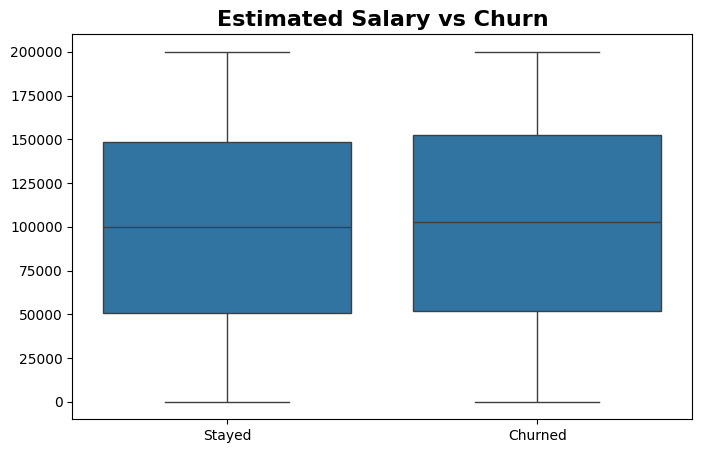

In [25]:
# boxplot, compare the estimated salary between stayed and churned customers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x='Exited', y='EstimatedSalary')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.xlabel('')
plt.ylabel('')
plt.title('Estimated Salary vs Churn', fontsize=16, weight = 'bold')
plt.show()

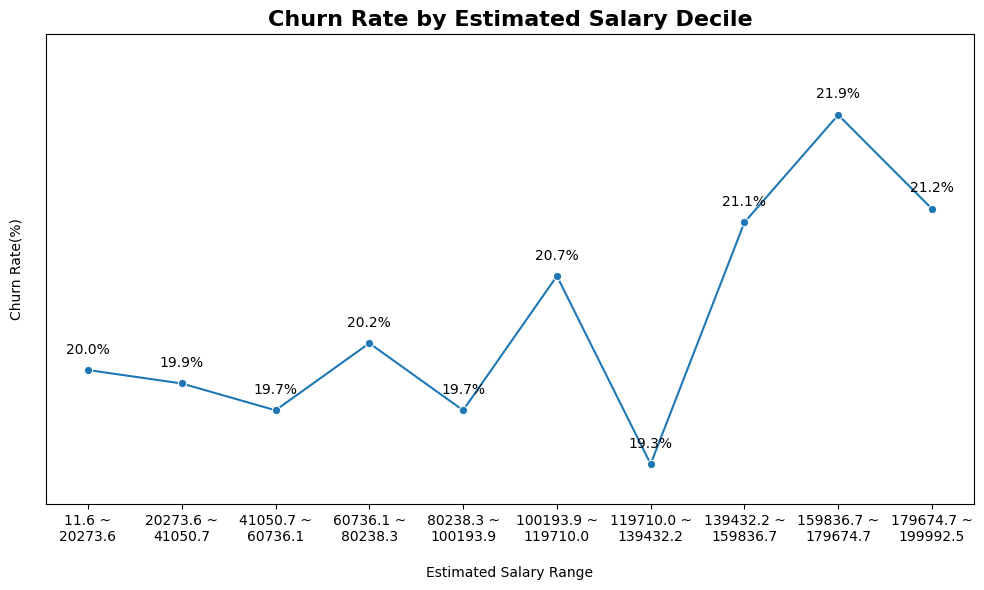

In [26]:
# line chart, analyzes how churn rate changes across different estimated salary ranges

# create 10 salary bins (deciles)
df_eda['SalaryBin'] = pd.qcut(df_eda['EstimatedSalary'], q=10, duplicates='drop')
# calculate churn rate for each estimated salary group
bin_churn = df_eda.groupby('SalaryBin', observed=False)['Exited'].mean().reset_index()
# format the salary range for the x-axis label
bin_churn['SalaryBinStr'] = bin_churn['SalaryBin'].apply(lambda x: f"{x.left:.1f} ~\n{x.right:.1f}")

plt.figure(figsize=(10, 6))
sns.lineplot(data=bin_churn, x='SalaryBinStr', y='Exited', marker='o')
# add data labels to each point
for i, row in bin_churn.iterrows():
    plt.text(i, row['Exited'] + 0.001, f"{row['Exited']:.1%}", ha='center', va='bottom', fontsize=10)

plt.xlabel('\nEstimated Salary Range')
plt.ylabel('Churn Rate(%)\n')
plt.ylim(0.19, 0.225)
plt.yticks(np.arange(0.19, 0.225, 0.005))
plt.yticks([])   # Hide y-axis ticks
# format y-axis values as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
plt.title('Churn Rate by Estimated Salary Decile', fontsize=16, weight = 'bold')
plt.tight_layout()
plt.show()

# Random Forest Model

## Random Forest - Data Preprocessing

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
df_rf = df.copy()

In [29]:
# remove unused fields
df_rf.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace = True)

In [30]:
# one-hot-encoding
df_rf = pd.get_dummies(df_rf, columns=['Geography', 'Gender'], drop_first=False)

In [31]:
# Separation of features and targets
x_rf = df_rf.drop('Exited', axis=1)
y_rf = df_rf['Exited']

print(f"Number of features: {x_rf.shape[1]}")
print(f"List of feature names: {list(x_rf.columns)}")

Number of features: 10
List of feature names: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [32]:
# Training/Test Splitting
# stratify=y_rf keeps the churn ratio consistent in both sets
Xrf_train, Xrf_test, yrf_train, yrf_test = train_test_split(x_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

print(f"Training sample size: {Xrf_train.shape[0]}")
print(f"Test sample size: {Xrf_test.shape[0]}")
print(f"Churn rate in training set: {yrf_train.mean():.2%}")
print(f"Churn rate in test set: {yrf_test.mean():.2%}")

Training sample size: 8000
Test sample size: 2000
Churn rate in training set: 20.38%
Churn rate in test set: 20.35%


## Random Forest model building and training

In [33]:
# create a Random Forest model with specific settings
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
# train the model
rf_model.fit(Xrf_train, yrf_train)

# predict for test data
yrf_pred = rf_model.predict(Xrf_test)
# predict probabilities
yrf_proba = rf_model.predict_proba(Xrf_test)[:, 1]

print(f" >>> Random Forest Model Training Completed")
print(f"  - Training set accuracy: {rf_model.score(Xrf_train, yrf_train):.3f}")
print(f"  - Test set accuracy: {rf_model.score(Xrf_test, yrf_test):.3f}")

 >>> Random Forest Model Training Completed
  - Training set accuracy: 0.897
  - Test set accuracy: 0.782


In [34]:
# model evaluation
print("=== Random Forest - Confusion Matrix ===")
print(confusion_matrix(yrf_test, yrf_pred))
print("\n=== Random Forest - Classification Report ===\n")
print(classification_report(yrf_test, yrf_pred, target_names=['Stayed', 'Churned']))
print(f"ROC AUC: {roc_auc_score(yrf_test, yrf_proba):.3f}")

=== Random Forest - Confusion Matrix ===
[[1360  233]
 [ 202  205]]

=== Random Forest - Classification Report ===

              precision    recall  f1-score   support

      Stayed       0.87      0.85      0.86      1593
     Churned       0.47      0.50      0.49       407

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000

ROC AUC: 0.777


In [35]:
precision, recall, threshold = precision_recall_curve(yrf_test, yrf_proba)
# calculate F1 score for each threshold
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)
# find the index of the best F1 score
best_rf_idx = f1_score.argmax()
# get the threshold that gives the best F1 score
best_rf_threshold = threshold[best_rf_idx]

print(f"The optimal F1 threshold: {best_rf_threshold:.2f}\nF1 Score: {f1_score[best_rf_idx]:.3f}")

The optimal F1 threshold: 0.46
F1 Score: 0.520


In [36]:
# get predicted probabilities for class 1 (Churned)
yrf_proba = rf_model.predict_proba(Xrf_test)[:, 1]

# predict class using the best threshold from F1 score
yrf_pred_opt = (yrf_proba > best_rf_threshold).astype(int)

# predict class using a fixed threshold
yrf_pred = (yrf_proba > 0.46).astype(int)

# evaluation
print("=== Random Forest - Confusion Matrix (best_rf_threshold) ===")
print(confusion_matrix(yrf_test, yrf_pred))
print("\n=== Random Forest - Classification Report (best_rf_threshold) ===")
print(classification_report(yrf_test, yrf_pred, target_names=['Stayed', 'Churned']))
print(f"ROC AUC: {roc_auc_score(yrf_test, yrf_proba):.3f}")

=== Random Forest - Confusion Matrix (best_rf_threshold) ===
[[1316  277]
 [ 171  236]]

=== Random Forest - Classification Report (best_rf_threshold) ===
              precision    recall  f1-score   support

      Stayed       0.89      0.83      0.85      1593
     Churned       0.46      0.58      0.51       407

    accuracy                           0.78      2000
   macro avg       0.67      0.70      0.68      2000
weighted avg       0.80      0.78      0.79      2000

ROC AUC: 0.777


In [37]:
# RF feature importance
feature_importance = pd.DataFrame({
    'Feature': x_rf.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"=== Random Forest - Feature Importance Ranking ===\n{feature_importance}")

=== Random Forest - Feature Importance Ranking ===
             Feature  Importance
1                Age    0.390893
4    EstimatedSalary    0.154208
0        CreditScore    0.144053
3            Balance    0.143238
2             Tenure    0.075431
6  Geography_Germany    0.038645
8      Gender_Female    0.016707
9        Gender_Male    0.014988
5   Geography_France    0.011808
7    Geography_Spain    0.010030


## Random Forest - ROC / PR Curve and Confusion Matrix

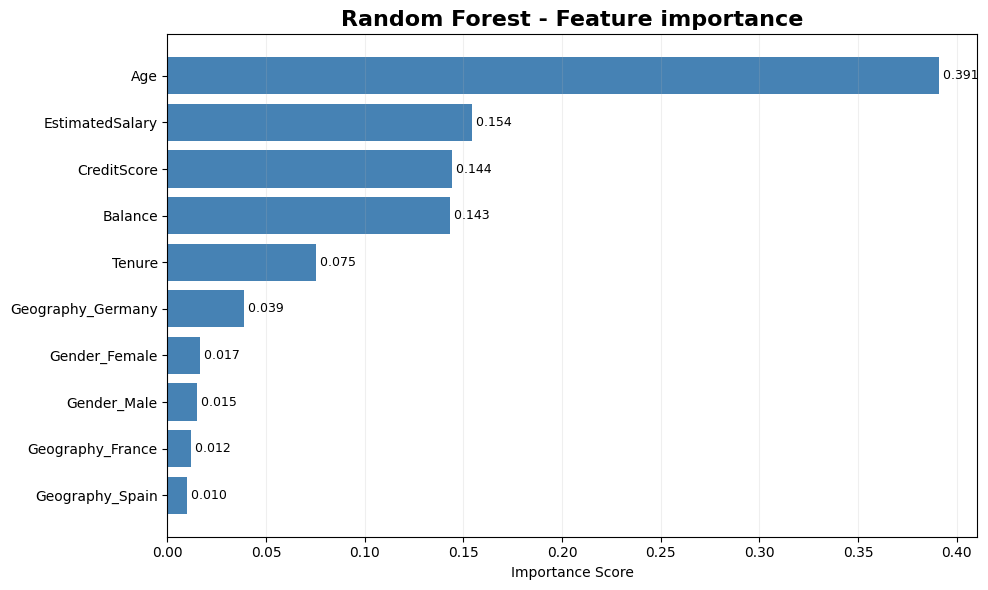

In [38]:
# horizontal bar chart, top 10 most important features in the Random Forest model
fig, ax7 = plt.subplots(figsize=(10, 6))

top_features = feature_importance.head(10)
ax7.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
ax7.set_yticks(range(len(top_features)))
ax7.set_yticklabels(top_features['Feature'])
ax7.set_xlabel('Importance Score')
ax7.set_title('Random Forest - Feature importance', fontsize=16, fontweight='bold')
ax7.invert_yaxis()
ax7.grid(axis='x', alpha=0.2)

# add data label
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax7.text(row['Importance'], i, f" {row['Importance']:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

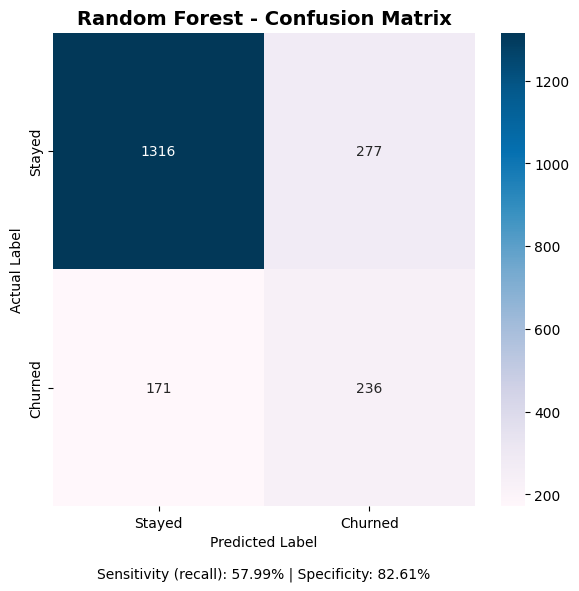

In [39]:
# Random Forest - Confusion Matrix
fig = plt.figure(figsize=(6, 6))

cm_rf = confusion_matrix(yrf_test, yrf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='PuBu',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')

# calculate confusion matrix metrics
tn, fp, fn, tp = cm_rf.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
plt.text(0.5, -0.15, f'\nSensitivity (recall): {sensitivity:.2%} | Specificity: {specificity:.2%}',
         ha='center', fontsize=10, transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

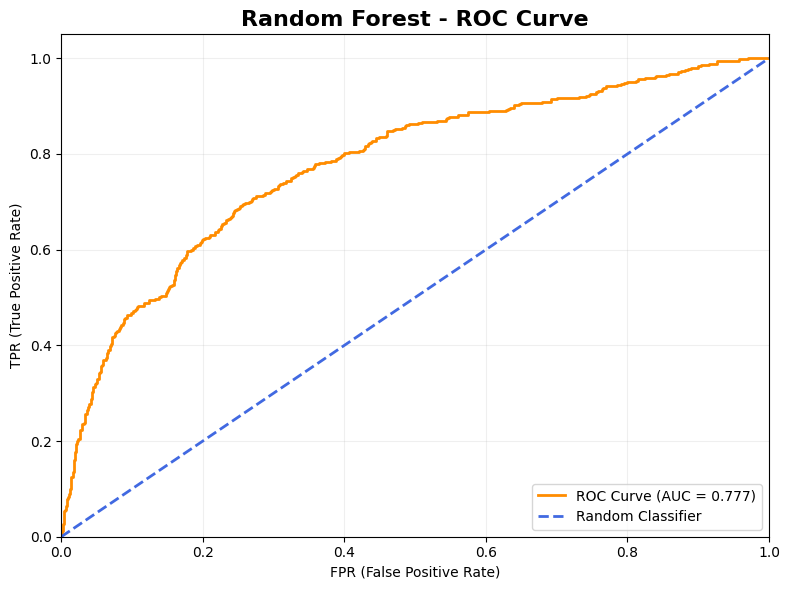

In [40]:
# Random Forest - ROC Curve
fig = plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(yrf_test, yrf_proba)
rf_roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {rf_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='royalblue', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.title('Random Forest - ROC Curve', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

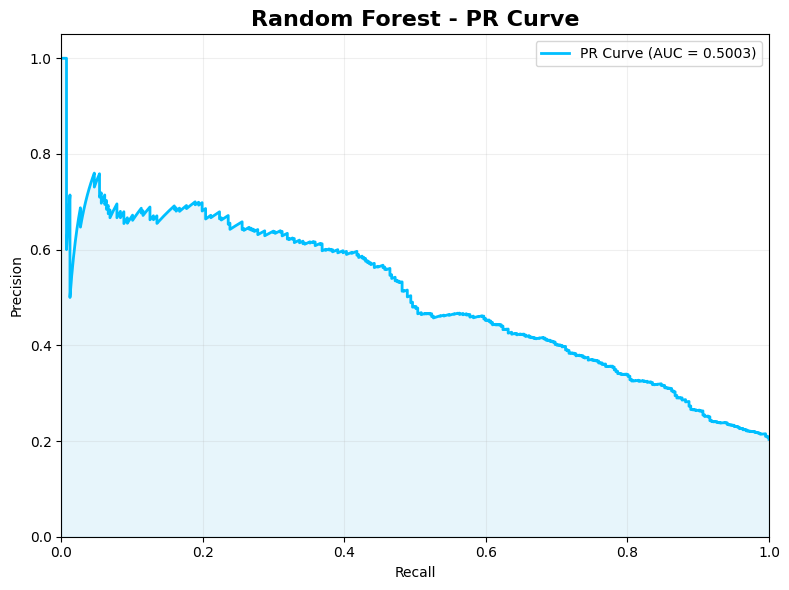

In [41]:
# Random Forest - PR Curve
fig = plt.figure(figsize=(8, 6))

rf_precision, rf_recall, _ = precision_recall_curve(yrf_test, yrf_proba)
rf_pr_auc = auc(rf_recall, rf_precision)
plt.plot(rf_recall, rf_precision, color='deepskyblue', lw=2, label=f'PR Curve (AUC = {rf_pr_auc:.4f})')
plt.fill_between(rf_recall, rf_precision, alpha=0.2, color='skyblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="upper right")
plt.grid(alpha=0.2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Random Forest - PR Curve', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# XGBoost Model

## XGBoost - Data Preprocessing

In [42]:
from xgboost import XGBClassifier

In [43]:
df_xgb = df.copy()

In [44]:
# remove unused fields
df_xgb.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace = True)

In [45]:
# one-hot-encoding
df_xgb = pd.get_dummies(df_xgb, columns=['Geography', 'Gender'], drop_first=False)

In [46]:
# Separation of features and targets
x_xgb = df_xgb.drop('Exited', axis=1)
y_xgb = df_xgb['Exited']

print(f"Number of features: {x_xgb.shape[1]}")
print(f"List of feature names: {list(x_xgb.columns)}")

Number of features: 10
List of feature names: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']


In [47]:
# Training/Test Splitting
# stratify=y_xgb keeps the churn ratio consistent in both sets
Xgb_train, Xgb_test, yxgb_train, yxgb_test = train_test_split(x_xgb, y_xgb, test_size=0.2, random_state=42, stratify=y_xgb)

print(f"Training sample size: {Xgb_train.shape[0]}")
print(f"Test sample size: {Xgb_test.shape[0]}")
print(f"Churn rate in training set: {yxgb_train.mean():.2%}")
print(f"Churn rate in tset set: {yxgb_test.mean():.2%}")

Training sample size: 8000
Test sample size: 2000
Churn rate in training set: 20.38%
Churn rate in tset set: 20.35%


## XGBoost Model building and training

In [48]:
# create XGBoost classification model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
# define the hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [2, 3, 3.91, 5, 10]
}
# use RandomizedSearchCV to find the best combination of hyperparameters
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
# train the model
random_search.fit(Xgb_train, yxgb_train)

print("Best parameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

# get the best XGBoost model from RandomizedSearchCV
xgb_best_model = random_search.best_estimator_
# predict for test data
yxgb_pred = xgb_best_model.predict(Xgb_test)
# predict probabilities for "churn"
yxgb_proba = xgb_best_model.predict_proba(Xgb_test)[:, 1]

print(f"\n>>> XGBoost Model Training Completed")
print(f"  - Training set accuracy: {xgb_best_model.score(Xgb_train, yxgb_train):.3f}")
print(f"  - Test set accuracy: {xgb_best_model.score(Xgb_test, yxgb_test):.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters:  {'subsample': 0.8, 'scale_pos_weight': 3, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best score:  0.5195426103237493

>>> XGBoost Model Training Completed
  - Training set accuracy: 0.782
  - Test set accuracy: 0.769


In [49]:
# model evaluation
print("=== XGBoost - Confusion Matrix ===")
print(confusion_matrix(yxgb_test, yxgb_pred))
print("\n=== XGBoost - Classification Report ===")
print(classification_report(yxgb_test, yxgb_pred, target_names=['Stayed', 'Churned']))
print(f"ROC AUC: {roc_auc_score(yxgb_test, yxgb_proba):.3f}")

=== XGBoost - Confusion Matrix ===
[[1277  316]
 [ 146  261]]

=== XGBoost - Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85      1593
     Churned       0.45      0.64      0.53       407

    accuracy                           0.77      2000
   macro avg       0.67      0.72      0.69      2000
weighted avg       0.81      0.77      0.78      2000

ROC AUC: 0.787


In [50]:
precisions, recalls, thresholds = precision_recall_curve(yxgb_test, yxgb_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_xgb_idx = f1_scores.argmax()
best_xgb_threshold = thresholds[best_xgb_idx]

print(f"The optimal F1 threshold: {best_xgb_threshold:.2f}\nF1 Score: {f1_scores[best_xgb_idx]:.3f}")

The optimal F1 threshold: 0.57
F1 Score: 0.551


In [51]:
yxgb_proba = xgb_best_model.predict_proba(Xgb_test)[:, 1]
yxgb_pred_opt = (yxgb_proba > best_xgb_threshold).astype(int)
yxgb_pred = (yxgb_proba > 0.57).astype(int)

# model evaluation
print("=== XGBoost - Confusion Matrix (best_xgb_threshold) ===")
print(confusion_matrix(yxgb_test, yxgb_pred))
print("\n=== XGBoost - Classification Report (best_xgb_threshold) ===")
print(classification_report(yxgb_test, yxgb_pred, target_names=['Stayed', 'Churned']))
print(f"ROC AUC: {roc_auc_score(yxgb_test, yxgb_proba):.3f}")

=== XGBoost - Confusion Matrix (best_xgb_threshold) ===
[[1365  228]
 [ 167  240]]

=== XGBoost - Classification Report (best_xgb_threshold) ===
              precision    recall  f1-score   support

      Stayed       0.89      0.86      0.87      1593
     Churned       0.51      0.59      0.55       407

    accuracy                           0.80      2000
   macro avg       0.70      0.72      0.71      2000
weighted avg       0.81      0.80      0.81      2000

ROC AUC: 0.787


In [52]:
# XGBoost feature importance
feature_importance = pd.DataFrame({
    'Feature': x_xgb.columns,
    'Importance': xgb_best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"=== XGBoost - Feature Importance Ranking ===\n{feature_importance}")

=== XGBoost - Feature Importance Ranking ===
             Feature  Importance
1                Age    0.292593
6  Geography_Germany    0.190289
9        Gender_Male    0.105817
8      Gender_Female    0.104412
3            Balance    0.080781
5   Geography_France    0.059287
7    Geography_Spain    0.057575
0        CreditScore    0.036741
2             Tenure    0.036507
4    EstimatedSalary    0.035998


## XGBoost - ROC / PR Curve and Confusion Matrix

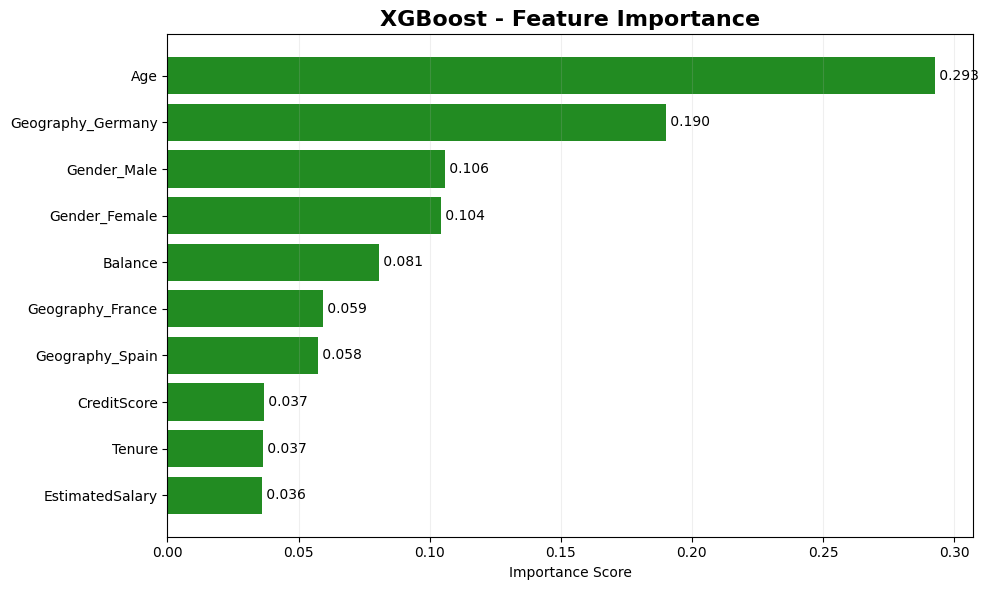

In [53]:
# horizontal bar chart, top 10 most important features in the XGBoost model
fig, ax11 = plt.subplots(figsize=(10, 6))

top_features = feature_importance.head(10)
bars = ax11.barh(range(len(top_features)), top_features['Importance'], color='forestgreen')
ax11.set_yticks(range(len(top_features)))
ax11.set_yticklabels(top_features['Feature'], fontsize=10)
ax11.set_xlabel('Importance Score', fontsize=10)
ax11.invert_yaxis()
ax11.grid(axis='x', alpha=0.2)
ax11.set_title('XGBoost - Feature Importance', fontsize=16, fontweight='bold')

for i, (idx, row) in enumerate(top_features.iterrows()):
    ax11.text(row['Importance'], i, f" {row['Importance']:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

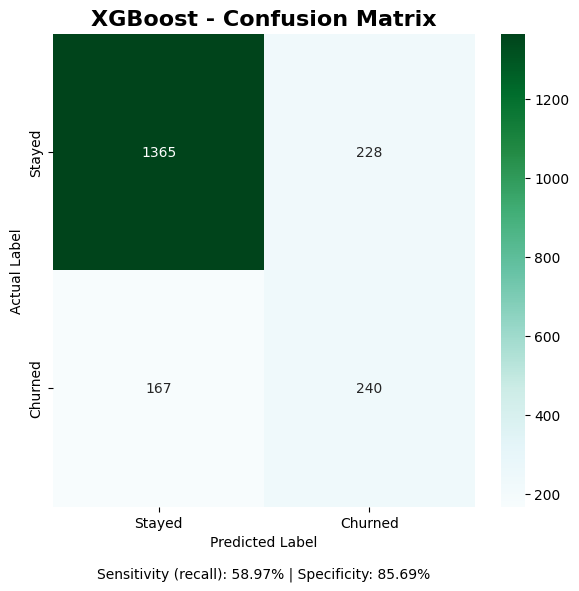

In [54]:
# XGBoost - Confusion Matrix
fig = plt.figure(figsize=(6, 6))

cm_xgb = confusion_matrix(yxgb_test, yxgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='BuGn',
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('XGBoost - Confusion Matrix', fontsize=16, fontweight='bold')

# Calculate confusion matrix metrics
tn, fp, fn, tp = cm_xgb.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
plt.text(0.5, -0.15, f'\nSensitivity (recall): {sensitivity:.2%} | Specificity: {specificity:.2%}',
         ha='center', fontsize=10, transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

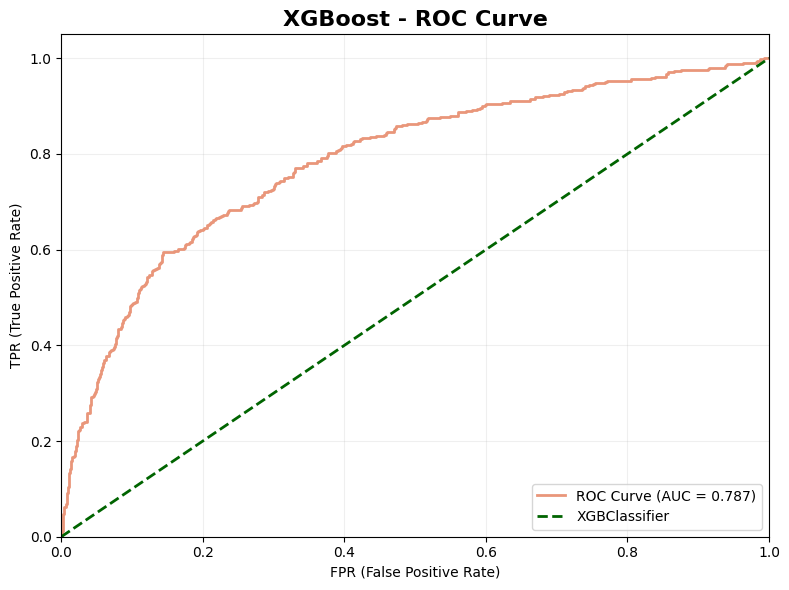

In [55]:
# XGBoost - ROC Curve
fig = plt.figure(figsize=(8, 6))

fpr, tpr, _ = roc_curve(yxgb_test, yxgb_proba)
xgb_roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darksalmon', lw=2, label=f'ROC Curve (AUC = {xgb_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='darkgreen', lw=2, linestyle='--', label='XGBClassifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.title('XGBoost - ROC Curve', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

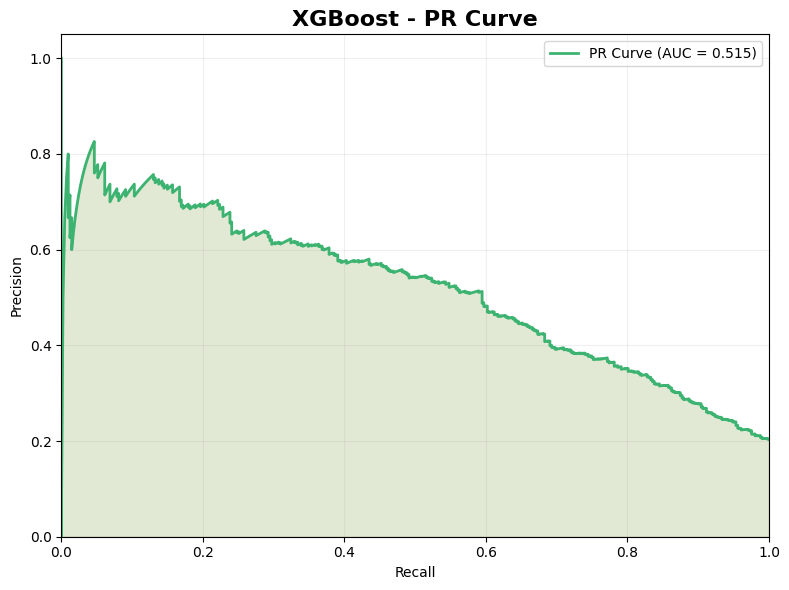

In [56]:
# XGBoost - PR Curve
fig = plt.figure(figsize=(8, 6))

xgb_precisions, xgb_recalls, xgb_thresholds = precision_recall_curve(yxgb_test, yxgb_proba)
xgb_pr_auc = auc(xgb_recalls, xgb_precisions)
plt.plot(xgb_recalls, xgb_precisions, color='mediumseagreen', lw=2, label=f'PR Curve (AUC = {xgb_pr_auc:.3f})')
plt.fill_between(xgb_recalls, xgb_precisions, alpha=0.2, color='olivedrab')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="upper right")
plt.grid(alpha=0.2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('XGBoost - PR Curve', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Customer Segmentation

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [62]:
df_seg = df.copy()

In [63]:
df_seg = df_seg.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [64]:
# Encoding
print("=== Encoding ===")

# save original values for reference
df_seg['Gender_Original'] = df_seg['Gender']
df_seg['Geography_Original'] = df_seg['Geography']

# Gender: Label Encoding
le_gender = LabelEncoder()
df_seg['Gender_Encoded'] = le_gender.fit_transform(df_seg['Gender'])
print(f"  - Gender Label Encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# Geography: One-Hot Encoding
geography_dummies = pd.get_dummies(df_seg['Geography'], prefix='Geography')
df_seg = pd.concat([df_seg, geography_dummies], axis=1)
print(f"  - Geography One-Hot Encoding: {geography_dummies.columns.tolist()}")

=== Encoding ===
  - Gender Label Encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
  - Geography One-Hot Encoding: ['Geography_France', 'Geography_Germany', 'Geography_Spain']


In [65]:
# feature selection
print("=== Select Features for Clustering ===")

numeric_features = ['Age', 'Tenure', 'Balance', 'EstimatedSalary', 'CreditScore']
gender_feature = ['Gender_Encoded']
geography_features = geography_dummies.columns.tolist()

# combine all features into one list
all_features = numeric_features + gender_feature + geography_features

# make a new DataFrame with selected features
X_seg = df_seg[all_features].copy()

print(f"Total features: {len(all_features)}")
print(f"  - Numeric: {numeric_features}")
print(f"  - Gender(Label): {gender_feature}")
print(f"  - Geography (One-Hot): {geography_features}")

=== Select Features for Clustering ===
Total features: 9
  - Numeric: ['Age', 'Tenure', 'Balance', 'EstimatedSalary', 'CreditScore']
  - Gender(Label): ['Gender_Encoded']
  - Geography (One-Hot): ['Geography_France', 'Geography_Germany', 'Geography_Spain']


In [66]:
# standardizes all features
print("=== Feature Standardization ===")

# create a scaler object
scaler = StandardScaler()
# fit the scaler and transform the data
X_seg_scaled = scaler.fit_transform(X_seg)
# convert result back to DataFrame with same column names and index
X_seg_scaled = pd.DataFrame(X_seg_scaled, columns=all_features, index=X_seg.index)

print(f" >>> Standardization completed")
print(f"  - Before standardization: Age [{X_seg['Age'].min():.2f}, {X_seg['Age'].max():.2f}]")
print(f"  - After standardization: Age [{X_seg_scaled['Age'].min():.2f}, {X_seg_scaled['Age'].max():.2f}]")

=== Feature Standardization ===
 >>> Standardization completed
  - Before standardization: Age [18.00, 92.00]
  - After standardization: Age [-1.99, 5.06]


In [67]:
# finds the best number of clusters (K) for K-Means
print("=== Elbow Method - Determine the optimal K value ===")

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_seg_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_seg_scaled, kmeans.labels_))
    print(f"   K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_score(X_seg_scaled, kmeans.labels_):.4f}")

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"\n💡 Best K value: {best_k_silhouette} (based on Silhouette Score)")

=== Elbow Method - Determine the optimal K value ===
   K=2: Inertia=72768.83, Silhouette=0.2013
   K=3: Inertia=58357.87, Silhouette=0.2745
   K=4: Inertia=53342.72, Silhouette=0.2199
   K=5: Inertia=50723.33, Silhouette=0.2009
   K=6: Inertia=48193.65, Silhouette=0.1836
   K=7: Inertia=46167.56, Silhouette=0.1656
   K=8: Inertia=43710.36, Silhouette=0.1785
   K=9: Inertia=41821.05, Silhouette=0.1906
   K=10: Inertia=40953.22, Silhouette=0.1761

💡 Best K value: 3 (based on Silhouette Score)


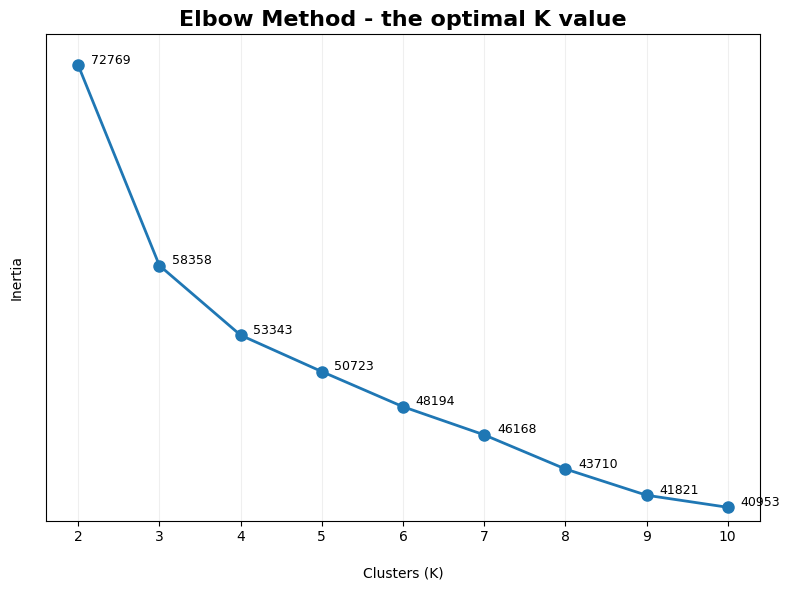

In [73]:
# line chart for Elbow Method
plt.subplots(figsize=(8, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)

# add data labels
for i, (x, y) in enumerate(zip(k_range, inertias)):
    plt.text(x + 0.4, y + 100, f'{y:.0f}', ha='center', fontsize=9)

plt.xlabel('\nClusters (K)')
plt.ylabel('Inertia\n')
plt.grid(alpha=0.2)
plt.xticks(k_range)
plt.ylim(40000, 75001)
plt.yticks([])
plt.title('Elbow Method - the optimal K value', fontsize=16, weight = 'bold')
plt.tight_layout()
plt.show()

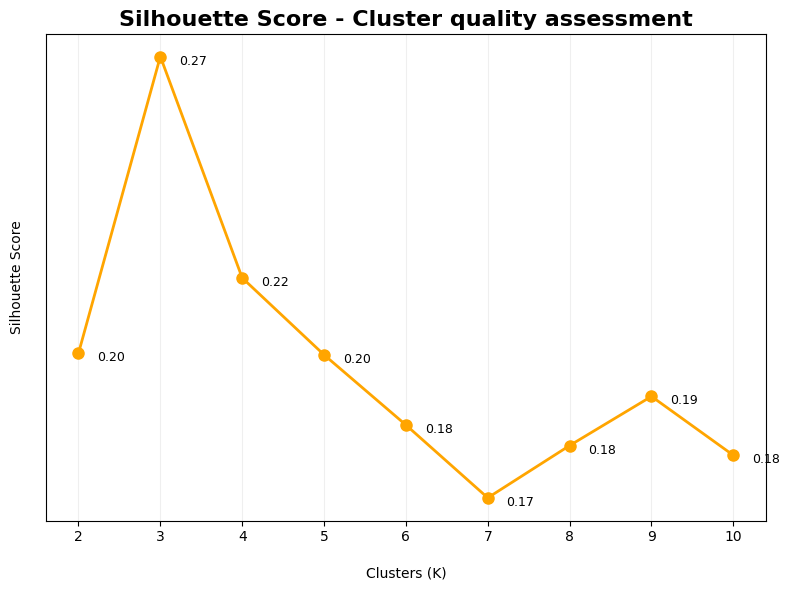

In [74]:
# line chart of Silhouette Scores
plt.subplots(figsize=(8, 6))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, markersize=8, color='orange')

# add data labels
for x, y in zip(k_range, silhouette_scores):
    plt.text(x + 0.4, y - 0.002, f'{y:.2f}', ha='center', fontsize=9)

plt.xlabel('\nClusters (K)')
plt.ylabel('Silhouette Score\n')
plt.grid(alpha=0.2)
plt.xticks(k_range)
plt.ylim(0.16, 0.28)
plt.yticks([])
plt.title('Silhouette Score - Cluster quality assessment', fontsize=16, weight = 'bold')
plt.tight_layout()
plt.show()

In [75]:
print("=== K-means Clustering ===")

# set the best K value
optimal_k = best_k_silhouette
# create K-Means model and fit it to the scaled data
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df_seg['Cluster'] = kmeans.fit_predict(X_seg_scaled)

print(f"Clustering done using K = {optimal_k}")
print(f"\nCluster member count:")

# show number of people in each cluster
for cluster_id in sorted(df_seg['Cluster'].unique()):
  count = (df_seg['Cluster'] == cluster_id).sum()
  pct = count / len(df_seg) * 100
  print(f"  - Group {cluster_id}: {count:5d} people ({pct:5.2f}%)")

# calculate clustering quality scores
silhouette = silhouette_score(X_seg_scaled, df_seg['Cluster'])  # Higher is better
davies_bouldin = davies_bouldin_score(X_seg_scaled, df_seg['Cluster'])  # Lower is better
print(f"\nClustering Quality Evaluation:")
print(f"   Silhouette Score: {silhouette:.4f}")
print(f"   Davies-Bouldin Index: {davies_bouldin:.4f}")

=== K-means Clustering ===
Clustering done using K = 3

Cluster member count:
  - Group 0:  5014 people (50.14%)
  - Group 1:  2477 people (24.77%)
  - Group 2:  2509 people (25.09%)

Clustering Quality Evaluation:
   Silhouette Score: 0.2745
   Davies-Bouldin Index: 1.5285


In [77]:
# analyzes and summarizes the main characteristics of each cluster
print("=== Cluster Profile Analysis ===")

cluster_profile = df_seg.groupby('Cluster').agg({
    'Gender_Encoded': 'mean',
    'Geography': lambda x: x.mode()[0] if len(x) > 0 else 0,
    'Age': 'mean',
    'Tenure': 'mean',
    'CreditScore':'mean',
    'Balance': 'mean',
    'EstimatedSalary': 'mean',
    'Exited': 'mean'  # churn rate
}).round(2)
# show customer count for each cluster
cluster_profile['Count'] = df_seg.groupby('Cluster').size()

print("\nCluster Profile Summary:")
print("=" * 90)
print(cluster_profile)

=== Cluster Profile Analysis ===

Cluster Profile Summary:
         Gender_Encoded Geography    Age  Tenure  CreditScore    Balance  \
Cluster                                                                    
0                  0.55    France  38.51    5.00       649.67   62092.64   
1                  0.56     Spain  38.89    5.03       651.33   61818.15   
2                  0.52   Germany  39.77    5.01       651.45  119730.12   

         EstimatedSalary  Exited  Count  
Cluster                                  
0               99899.18    0.16   5014  
1               99440.57    0.17   2477  
2              101113.44    0.32   2509  


=== Cluster Churn Rate Analysis ===

Churn Rate by Cluster(Sorted):
Group 2: Churn Rate 32.44% | Churned  814 / Total 2509 users

Group 1: Churn Rate 16.67% | Churned  413 / Total 2477 users

Group 0: Churn Rate 16.15% | Churned  810 / Total 5014 users



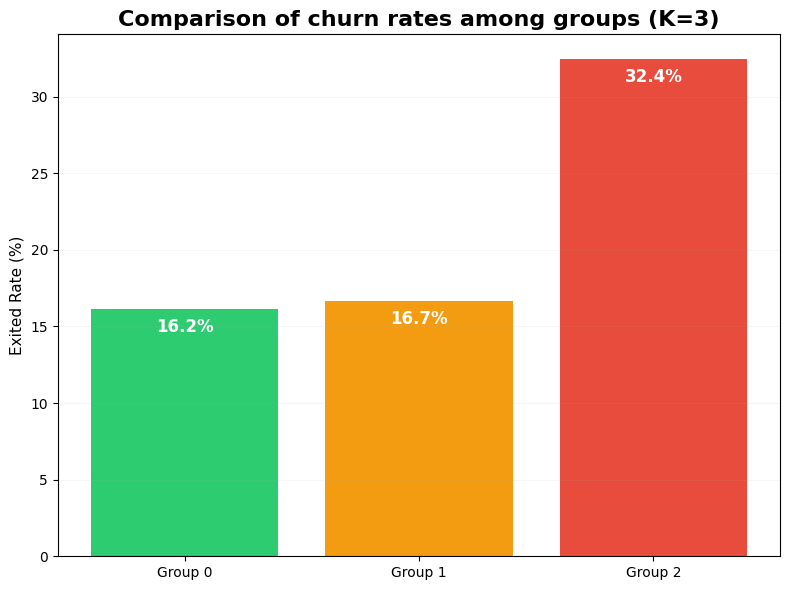

In [81]:
# analyzes and visualizes the churn rate for each customer group
print("=== Cluster Churn Rate Analysis ===")

# Group by cluster and calculate
#  - sum of churned users
#  - total users
#  - average churn rate
churn_by_cluster = df_seg.groupby('Cluster')['Exited'].agg(['sum', 'count', 'mean']).round(4)
churn_by_cluster.columns = ['Churned_Count', 'Total_Count', 'Churn_Rate']
churn_by_cluster = churn_by_cluster.sort_values('Churn_Rate', ascending=False)

print("\nChurn Rate by Cluster(Sorted):")
print("=" * 60)
for idx, row in churn_by_cluster.iterrows():
    print(f"Group {idx}: Churn Rate {row['Churn_Rate']*100:5.2f}% | "
          f"Churned {int(row['Churned_Count']):4d} / Total {int(row['Total_Count']):4d} users\n")

# bar chart for each group
fig, ax4 = plt.subplots(figsize=(8, 6))

clusters = churn_by_cluster.index
churn_rates = churn_by_cluster['Churn_Rate'] * 100

# add data labels
for i, (cluster, rate) in enumerate(zip(clusters, churn_rates)):
    ax4.text(cluster, rate - 1.5, f'{rate:.1f}%', ha='center', fontweight='bold',color = 'white',fontsize=12)

bars = ax4.bar(clusters, churn_rates, color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'][:len(clusters)])
ax4.set_xlabel('')
ax4.set_xticks(clusters)
ax4.set_xticklabels([f'Group {i}' for i in clusters])
ax4.set_ylabel('Exited Rate (%)', fontsize=11)
ax4.grid(axis='y', alpha=0.1)
ax4.set_title(f'Comparison of churn rates among groups (K={optimal_k})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [82]:
from sklearn.preprocessing import MinMaxScaler
from math import pi

=== Radar Chart for Cluster Features ===



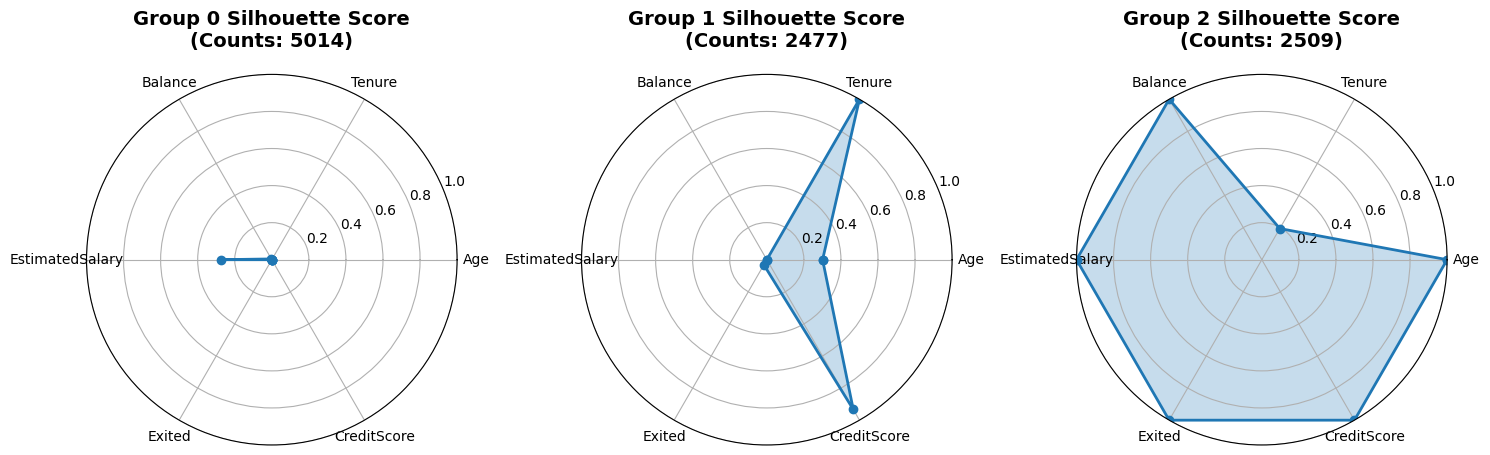

In [83]:
# radar charts, show the average features of each group after scaling the values
print("=== Radar Chart for Cluster Features ===\n")

# select features to show on the radar chart
radar_features = ['Age', 'Tenure', 'Balance', 'EstimatedSalary', 'Exited', 'CreditScore']
# calculate the average value of each feature in every cluster
radar_data = df_seg.groupby('Cluster')[radar_features].mean()

# normalize features to 0–1 range
scaler_radar = MinMaxScaler()
radar_data_scaled = pd.DataFrame(
    scaler_radar.fit_transform(radar_data),
    columns=radar_features,
    index=radar_data.index
)

# create one polar plot for each cluster
fig, axes1 = plt.subplots(1, optimal_k, figsize=(5*optimal_k, 5), subplot_kw=dict(projection='polar'))

# if only one cluster, wrap axis in a list
if optimal_k == 1:
    axes1 = [axes1]

categories = radar_features
N = len(categories)
# radar chart for each group
for idx, cluster_id in enumerate(sorted(df_seg['Cluster'].unique())):
    ax5 = axes1[idx]
    # get scaled values for this cluster
    values = radar_data_scaled.loc[cluster_id].values.tolist()
    values += values[:1]
    # set angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    ax5.plot(angles, values, 'o-', linewidth=2, label=f'Group {cluster_id}')
    ax5.fill(angles, values, alpha=0.25)
    # set labels and appearance
    ax5.set_xticks(angles[:-1])
    ax5.set_xticklabels(categories)
    ax5.set_ylim(0, 1)
    ax5.grid(True)
    # add title with group number and member count
    ax5.set_title(f'Group {cluster_id} Silhouette Score\n(Counts: {(df_seg["Cluster"]==cluster_id).sum()})',
                 fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

=== Cluster Features ===



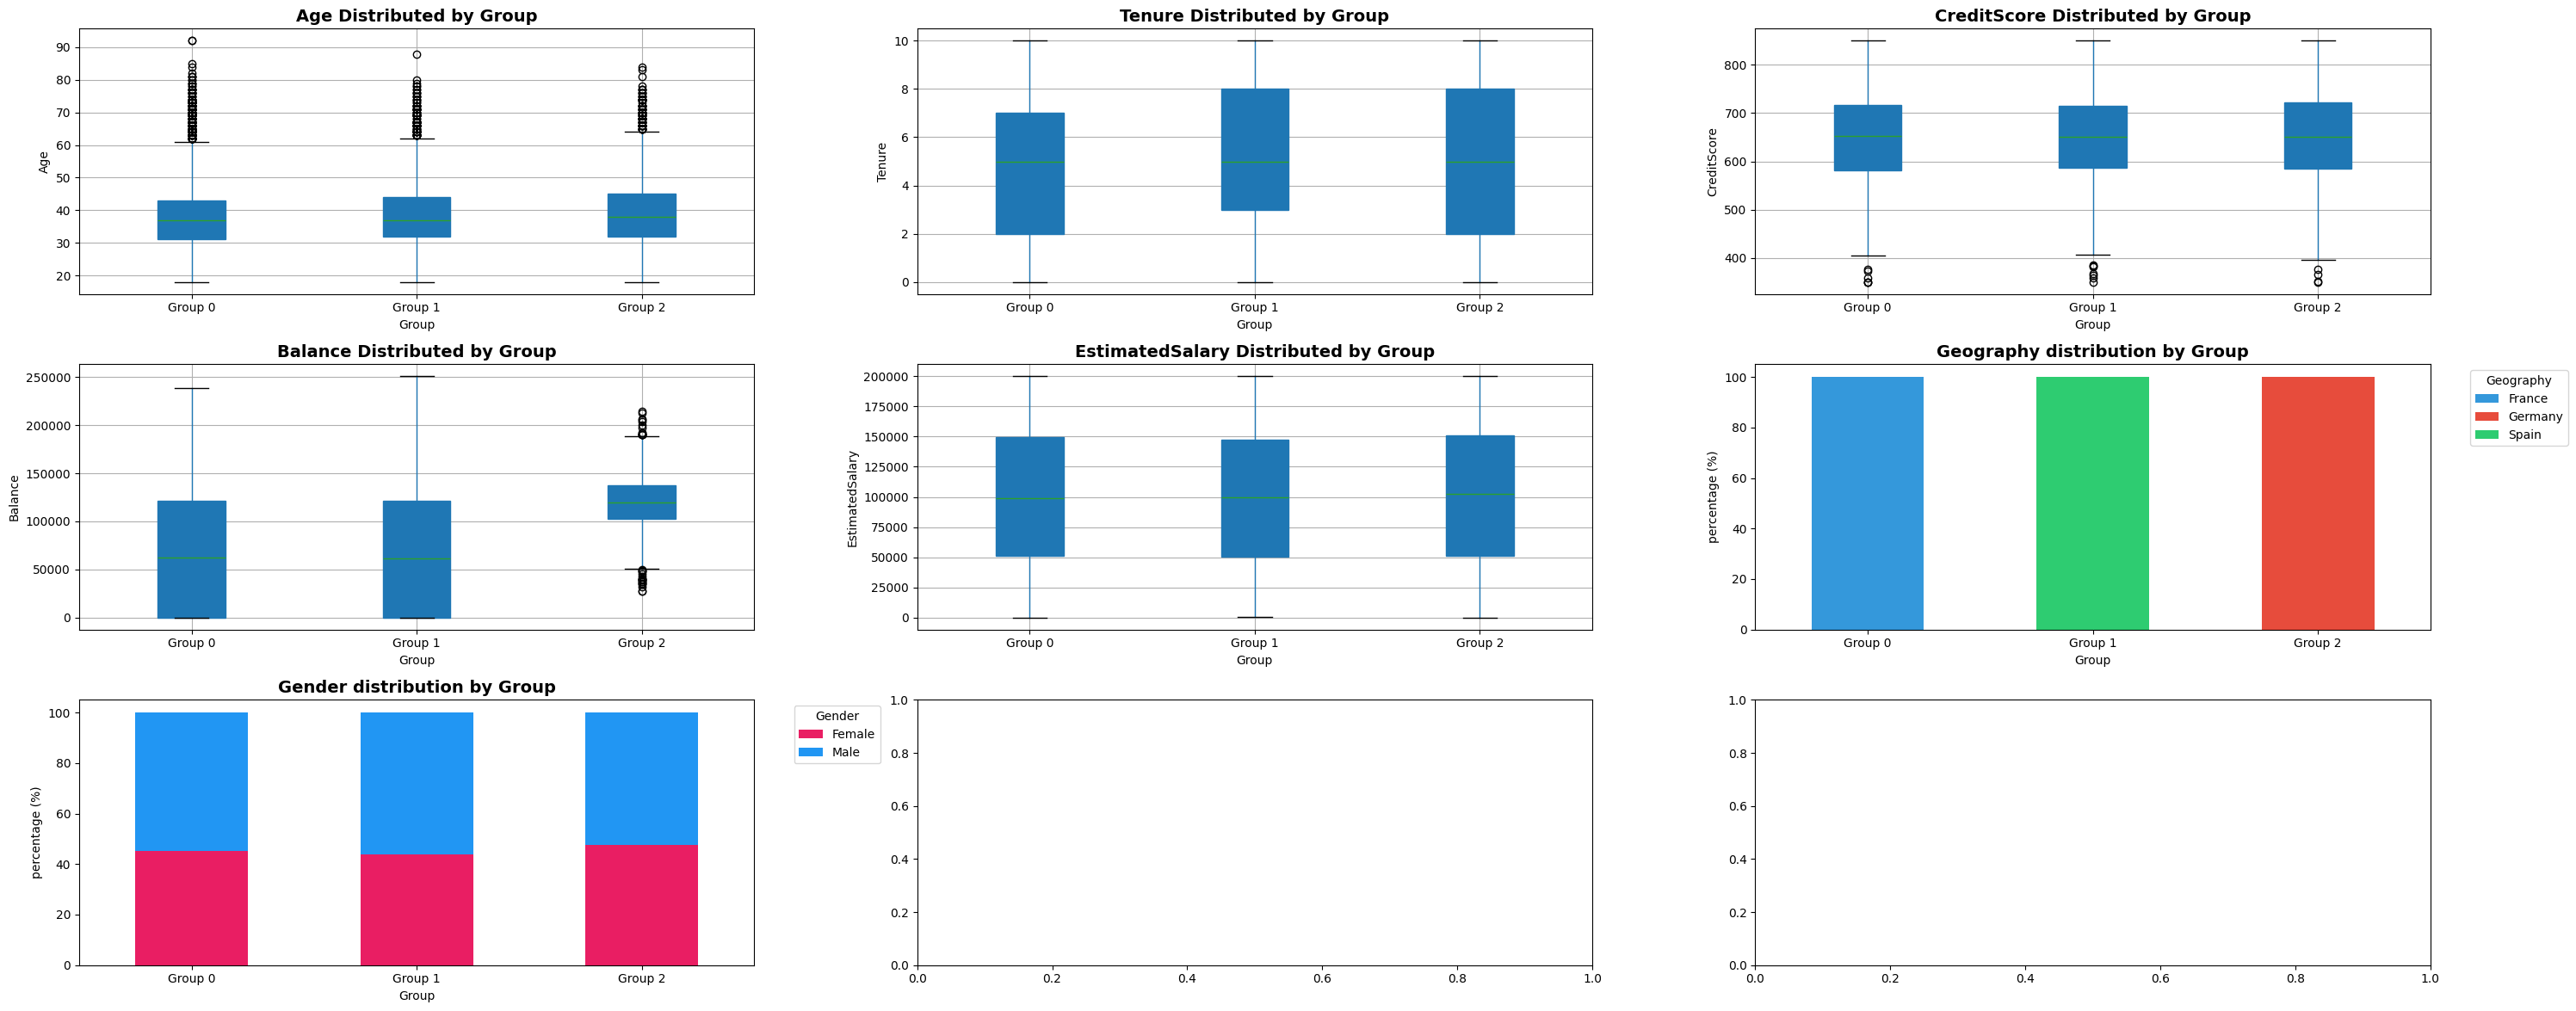

In [84]:
# boxplots and bar charts, show the distribution of customer features in each group.
print("=== Cluster Features ===\n")

# create subplot grid (3 rows, 3 columns)
fig, axes2 = plt.subplots(3, 3, figsize=(30, 12))
axes2 = axes2.ravel()
# define the numeric features to plot
numeric_features = ['Age', 'Tenure','CreditScore', 'Balance', 'EstimatedSalary']

# create boxplot for each numeric feature by cluster
for idx, feature in enumerate(numeric_features):
    ax = axes2[idx]
    df_seg.boxplot(column=feature, by='Cluster', ax=ax, patch_artist=True)
    ax.set_xlabel('Group')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} Distributed by Group', fontsize=14, fontweight='bold')
    plt.sca(ax)
    plt.xticks(range(1, optimal_k+1), [f'Group {i}' for i in range(optimal_k)])

# Geography distribution (bar chart)
ax = axes2[5]
geography_dist = pd.crosstab(df_seg['Cluster'], df_seg['Geography_Original'], normalize='index') * 100
geography_dist.plot(kind='bar', stacked=True, ax=ax,
                    color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_xlabel('Group')
ax.set_ylabel('percentage (%)')
ax.legend(title='Geography', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels([f'Group {i}' for i in range(optimal_k)], rotation=0)
ax.set_title('Geography distribution by Group', fontsize=14, fontweight='bold')

# Gender distribution (stacked bar)
ax = axes2[6]
gender_dist = pd.crosstab(df_seg['Cluster'], df_seg['Gender_Original'], normalize='index') * 100
gender_dist.plot(kind='bar', stacked=True, ax=ax,
                 color=['#e91e63', '#2196f3'])
ax.set_xlabel('Group')
ax.set_ylabel('percentage (%)')
ax.legend(title='Gender', bbox_to_anchor=(1.05, 1))
ax.set_xticklabels([f'Group {i}' for i in range(optimal_k)], rotation=0)
ax.set_title('Gender distribution by Group', fontsize=14, fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [85]:
from sklearn.decomposition import PCA

In [86]:
# uses PCA to reduce the data to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg_scaled)

# save PCA results back to the dataframe
df_seg['PCA1'] = X_pca[:, 0]
df_seg['PCA2'] = X_pca[:, 1]

print(f"PCA Explained Variance:")
print(f"  - PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  - PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  - Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PCA Explained Variance:
  - PC1: 20.43%
  - PC2: 16.45%
  - Total: 36.89%


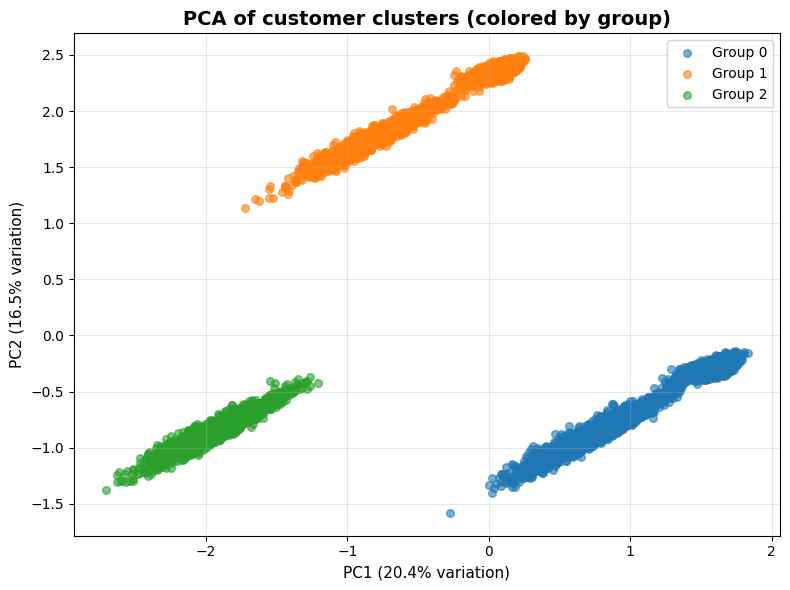

In [88]:
# scatter plot, colored by group
plt.subplots(figsize=(8, 6))
# loop through each cluster and plot the points
for cluster_id in sorted(df_seg['Cluster'].unique()):
    cluster_data = df_seg[df_seg['Cluster'] == cluster_id]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'],
               label=f'Group {cluster_id}', alpha=0.6, s=30)
# set axis labels with explained variance info
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variation)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variation)', fontsize=11)

plt.legend()
plt.grid(alpha=0.3)
plt.title('PCA of customer clusters (colored by group)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

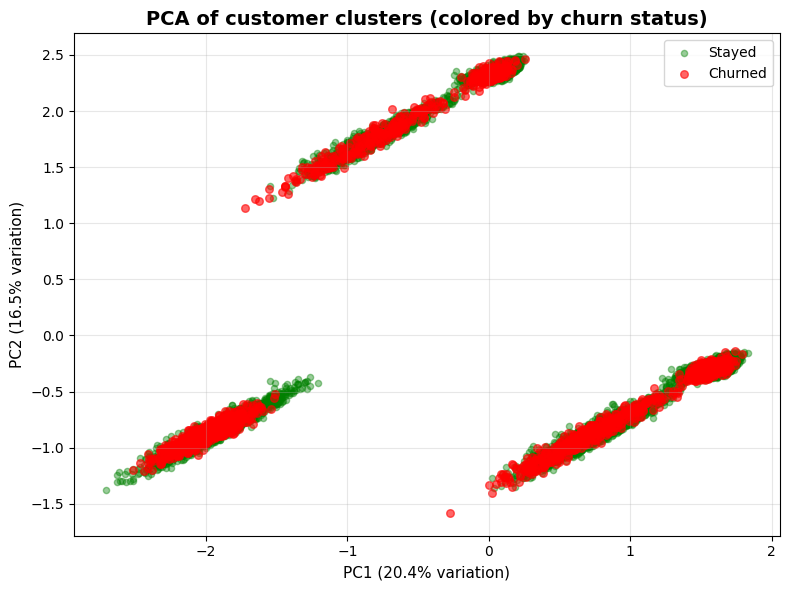

In [89]:
# scatter plot, colored by churn status
plt.subplots(figsize=(8, 6))
# separate churned and stayed customers
churned = df_seg[df_seg['Exited'] == 1]
stayed = df_seg[df_seg['Exited'] == 0]
# stayed - green
plt.scatter(stayed['PCA1'], stayed['PCA2'],
           label='Stayed', alpha=0.4, s=20, color='green')
# churned - red
plt.scatter(churned['PCA1'], churned['PCA2'],
           label='Churned', alpha=0.6, s=30, color='red')

# add axis labels with explained variance
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variation)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variation)', fontsize=11)

plt.legend()
plt.grid(alpha=0.3)
plt.title('PCA of customer clusters (colored by churn status)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [92]:
# summarizes the key characteristics of each customer cluster and assigns a risk level
print("=== Summary of Each Group ===\n")

for cluster_id in sorted(df_seg['Cluster'].unique()):
  # Filter data for the current cluster
  cluster_data = df_seg[df_seg['Cluster'] == cluster_id]

  # calculate statistics for the current cluster
  avg_age = cluster_data['Age'].mean()
  avg_tenure = cluster_data['Tenure'].mean()
  avg_balance = cluster_data['Balance'].mean()
  avg_salary = cluster_data['EstimatedSalary'].mean()
  churn_rate = cluster_data['Exited'].mean() * 100
  count = len(cluster_data)

  print(f"Group {cluster_id} ({count} customers, {count/len(df_seg)*100:.1f}%):")
  print(f"   Avg. Age: {avg_age:.1f} years")
  print(f"   Avg. Tenure: {avg_tenure:.1f} years")
  print(f"   Avg. Balance: ${avg_balance:,.0f}")
  print(f"   Avg. Salary: ${avg_salary:,.0f}")
  print(f"   Churn Rate: {churn_rate:.0f}%")

  # assign churn risk level based on churn rate
  if churn_rate > 30:
    risk_level = "🔴 High Risk"
  elif churn_rate > 20:
    risk_level = "🟡 Medium Risk"
  else:
    risk_level = "🟢 Low Risk"
  print(f"   Risk Level: {risk_level}")

=== Summary of Each Group ===

Group 0 (5014 customers, 50.1%):
   Avg. Age: 38.5 years
   Avg. Tenure: 5.0 years
   Avg. Balance: $62,093
   Avg. Salary: $99,899
   Churn Rate: 16%
   Risk Level: 🟢 Low Risk
Group 1 (2477 customers, 24.8%):
   Avg. Age: 38.9 years
   Avg. Tenure: 5.0 years
   Avg. Balance: $61,818
   Avg. Salary: $99,441
   Churn Rate: 17%
   Risk Level: 🟢 Low Risk
Group 2 (2509 customers, 25.1%):
   Avg. Age: 39.8 years
   Avg. Tenure: 5.0 years
   Avg. Balance: $119,730
   Avg. Salary: $101,113
   Churn Rate: 32%
   Risk Level: 🔴 High Risk


In [95]:
print("=== Retention Strategy Recommendations ===\n")
print(f"🟢 Group 0")
print(f"Action: Offer upgrade plans, encourage referrals\n")

print(f"🟢 Group 1")
print(f"Action: Improve user onboarding and collect feedback\n")

print(f"🔴 Group 2")
print(f"Action: Give special discounts, optimize user experience")

=== Retention Strategy Recommendations ===

🟢 Group 0
Action: Offer upgrade plans, encourage referrals

🟢 Group 1
Action: Improve user onboarding and collect feedback

🔴 Group 2
Action: Give special discounts, optimize user experience
